In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import linregress
from collections import defaultdict
import matplotlib as mpl
from cycler import cycler
import numpy as np
import os
import json
import sys
import glob

In [2]:
PALETTE = ['#007191', '#f47a00', '#62c8d3', '#c31e23', '#ff5a5e', '#fbac2b']

mpl.rcParams['axes.prop_cycle'] = cycler(color=PALETTE)
sns.set_palette(PALETTE)

METHOD_COLORS = {
    "DCD_L2_perm":  "#007191",  # dark teal
    "LinearSVC_L1": "#f47a00",  # orange
    "LinearSVC_L2": "#62c8d3",  # light teal
    "SVC_linear":   "#c31e23",  # dark red
    "DCD_L1_perm":  "#ff5a5e",  # pink
    "DCD_L1_perm_shrink":'#fbac2b',
    "DCD_L2_perm_shrink": "#621556"

}

IMPL_COLORS = {"our implementation": "#007191", "sklearn": "#f47a00"}
PENALTY_COLORS = {"L1": "#007191", "L2": "#f47a00"}


In [3]:
phase1 = pd.read_csv("../results/phase_1.csv")
phase2 = pd.read_csv("../results/phase_2.csv")
phase3 = pd.read_csv("../results/phase_3.csv")
phase4 = pd.read_csv("../results/phase_4.csv")
phase5 = pd.read_csv("../results/phase_5.csv")

## PHASE 1 - Methods comparison

In [4]:
phase1["method_type"] = np.where(
    phase1["method"].str.contains("dcd", case=False, na=False),
    "our implementation",
    "sklearn"
)

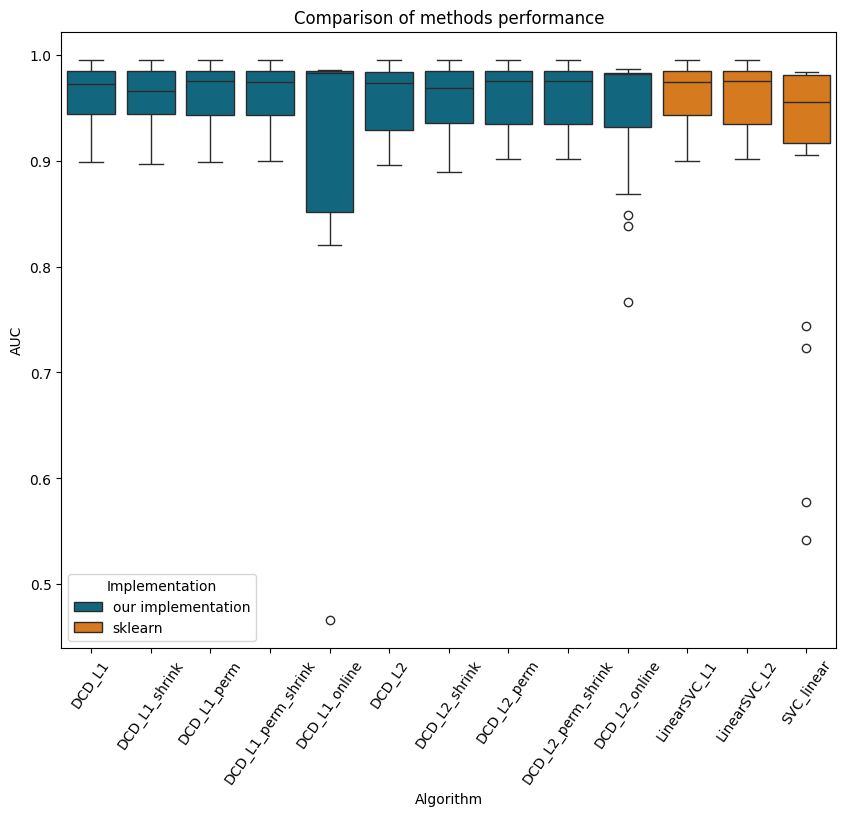

In [5]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1, x="method", y="auc", hue="method_type", palette=IMPL_COLORS)
plt.xticks(rotation=55)
plt.legend(title="Implementation")
plt.xlabel("Algorithm")
plt.ylabel("AUC")
plt.title("Comparison of methods performance")
plt.show()


/opt/anaconda3/envs/vllm-cpu/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/vllm-cpu/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/vllm-cpu/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 72.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/vllm-cpu/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/vllm-cpu/lib/python3.11/s

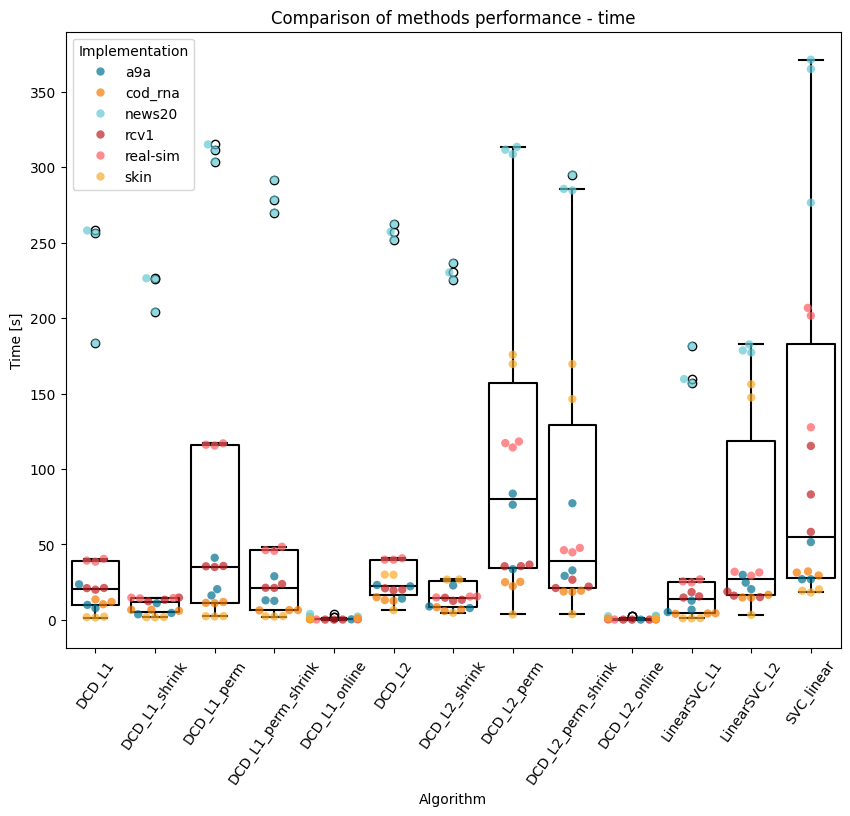

In [28]:
plt.figure(figsize=(10,8))
# sns.boxplot(data=phase1, x="method", y="time_s", hue="method_type", palette=IMPL_COLORS)
sns.boxplot(data=phase1, x="method", y="time_s", fill=False, color="black")
sns.swarmplot(data=phase1, x="method", y="time_s", hue="dataset", size=6, alpha=0.7)
plt.xticks(rotation=55)
plt.legend(title="Implementation")
plt.xlabel("Algorithm")
plt.ylabel("Time [s]")
plt.title("Comparison of methods performance - time")
plt.show()


In [18]:
phase1_own = phase1[phase1["method_type"] == "our implementation"]
phase1_own["method_type"] = np.where(
    phase1_own["method"].str.contains("L1", case=False, na=False),
    "L1",
    "L2"
)
phase1_own["method"] = phase1_own["method"].str.split("_").str[2:].str.join("_")
phase1_own["method"] = phase1_own["method"].replace("", "base")

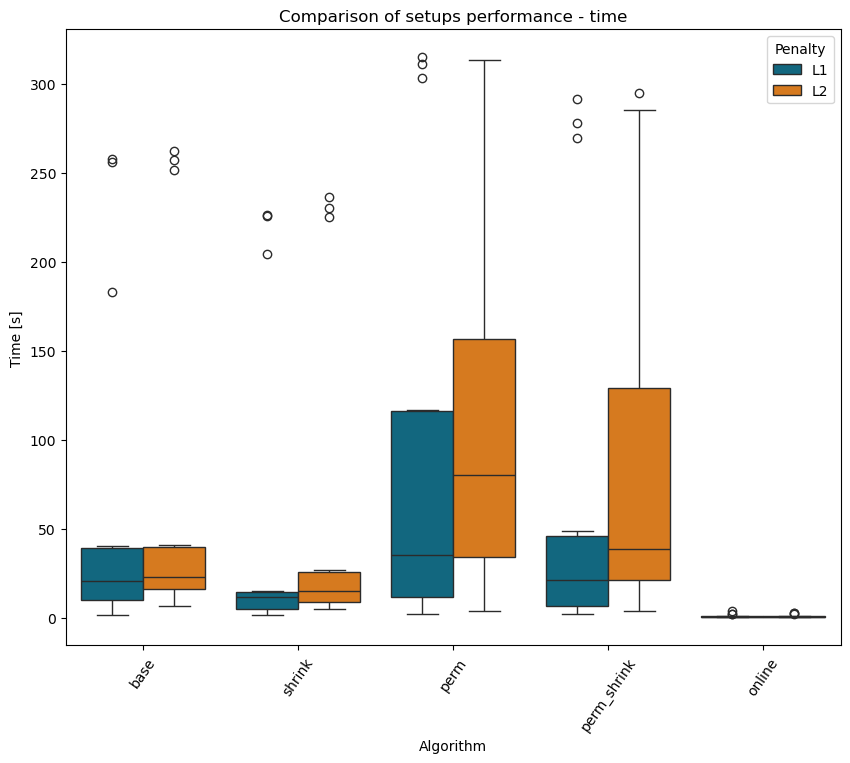

In [19]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1_own, x="method", y="time_s", hue="method_type", palette=PENALTY_COLORS)
plt.xticks(rotation=55)
plt.legend(title="Penalty")
plt.xlabel("Algorithm")
plt.ylabel("Time [s]")
plt.title("Comparison of setups performance - time")
plt.show()


## PHASE 2 - Penalty parameter C

In [20]:
phase2["method_type"] = np.where(
    phase2["method"].str.contains("dcd", case=False, na=False),
    "our implementation",
    "sklearn"
)

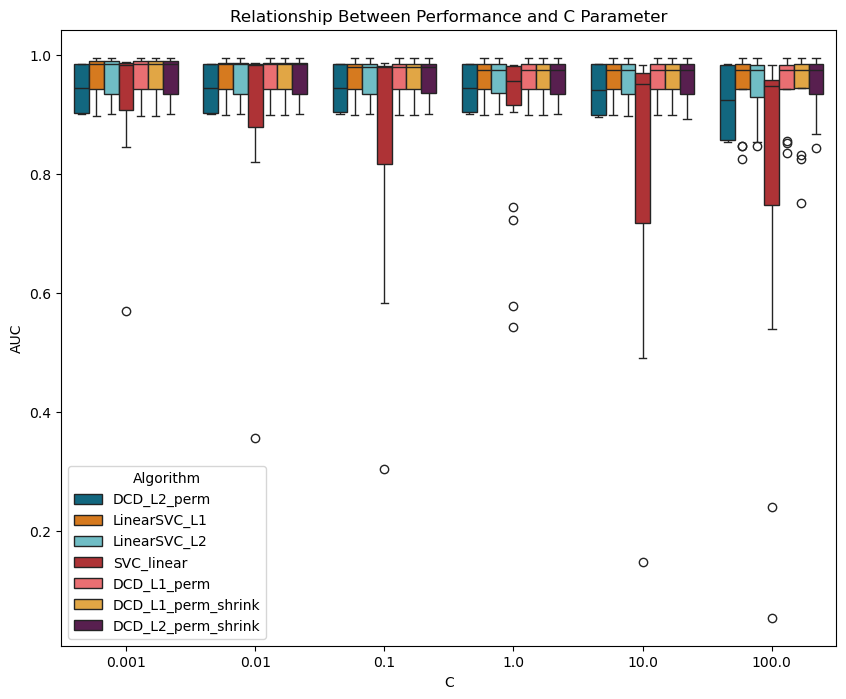

In [21]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase2, x="C", y="auc", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="lower left")
plt.xlabel("C")
plt.ylabel("AUC")
plt.title("Relationship Between Performance and C Parameter")
plt.show()


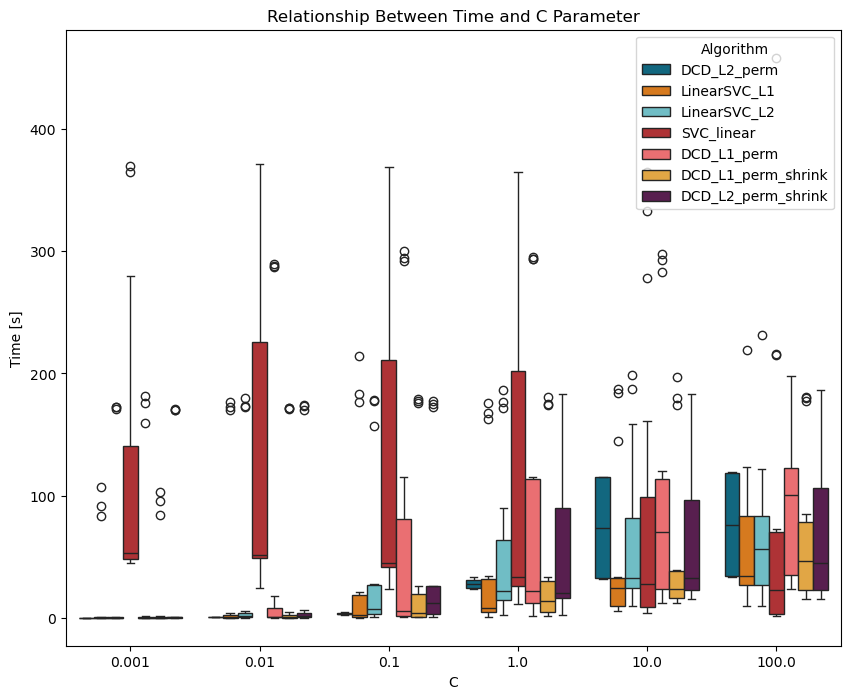

In [22]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase2, x="C", y="time_s", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("C")
plt.ylabel("Time [s]")
plt.title("Relationship Between Time and C Parameter")
plt.show()


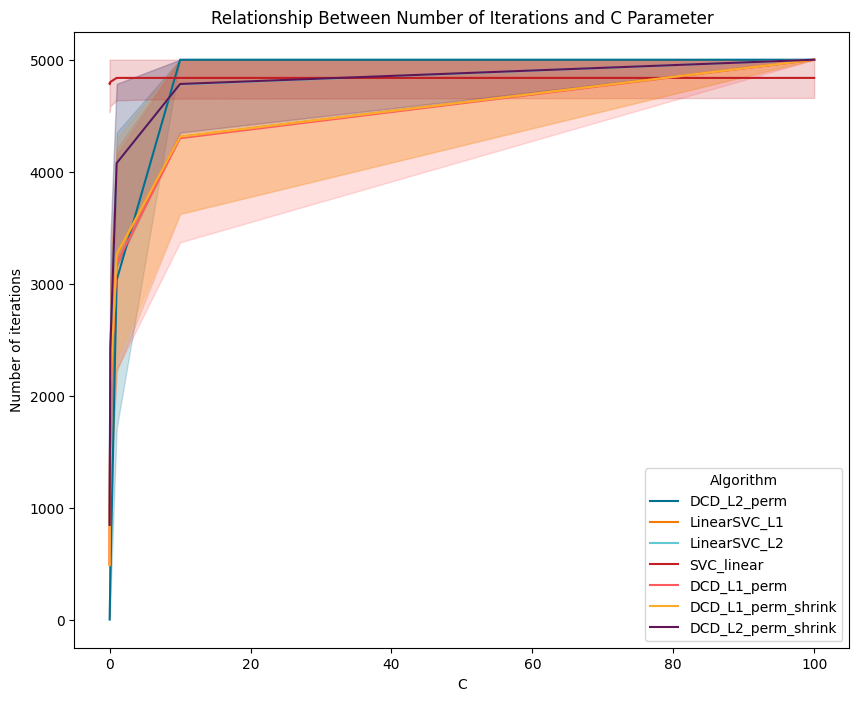

In [29]:
plt.figure(figsize=(10,8))
sns.lineplot(data=phase2, x="C", y="n_iter", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="lower right")
plt.xlabel("C")
plt.ylabel("Number of iterations")
plt.title("Relationship Between Number of Iterations and C Parameter")
# plt.xscale("log")
plt.show()


## PHASE 3 - Scalability analysis

In [32]:
phase3["time_s"] = (
    phase3["time_s"]
    .replace("Timeout >500s", 500)
    .astype(float)
)

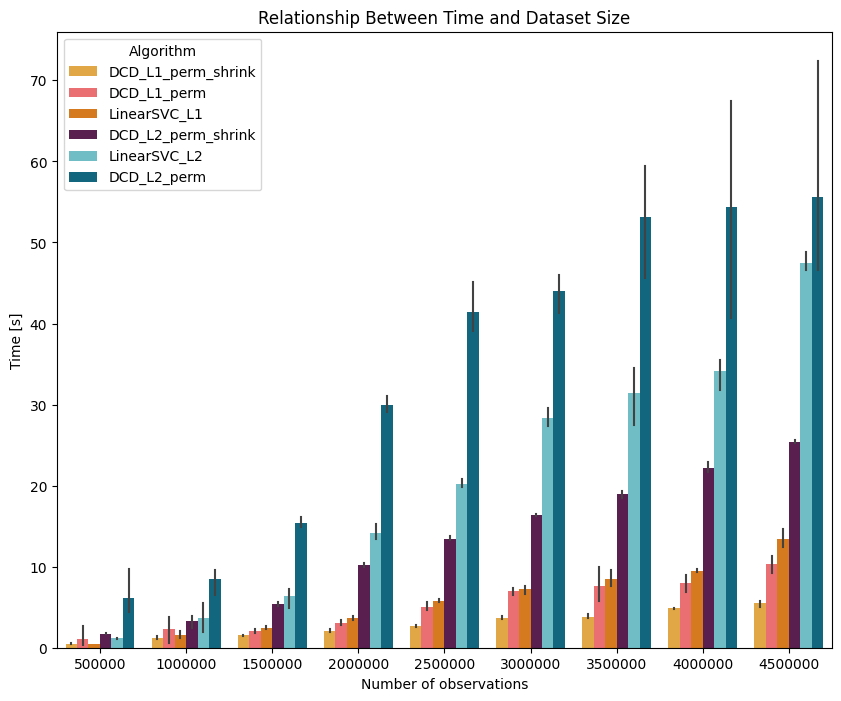

In [ ]:
total_rows = sum(1 for line in open("../data/SUSY"))
# total_rows = 5 * 1e6

phase3["n_samples"] = (phase3["fraction"] * total_rows).astype(int)

plot_data = phase3[phase3["method"] != "SVC_linear"]
order = plot_data.groupby("method")["time_s"].mean().sort_values().index

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_data, 
    x="n_samples",     
    y="time_s", 
    hue="method",
    palette=METHOD_COLORS,
    hue_order=order,
    err_kws={"linewidth": 1.5}
)

plt.legend(title="Algorithm", loc="upper left")
plt.xlabel("Number of observations")
plt.ylabel("Time [s]")
plt.title("Relationship Between Time and Dataset Size")

plt.show()


## PHASE 4 - Sparsity impact

In [58]:
phase4["time_s"] = (
    phase4["time_s"]
    .replace(["Timeout >500s", "Skipped (prior timeout)"], 500)
    .astype(float)
)

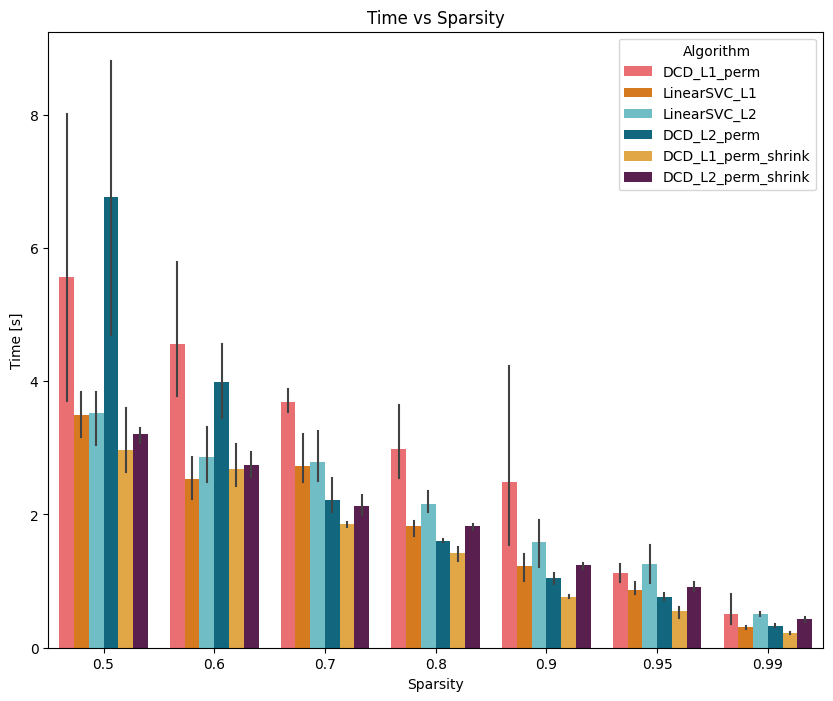

In [80]:
plot_data = phase4[phase4["method"] != "SVC_linear"]

plt.figure(figsize=(10,8))
sns.barplot(data=plot_data,
            x="sparsity", 
            y="time_s", 
            hue="method", 
            palette=METHOD_COLORS, 
            err_kws={"linewidth" : 1.5}
            )
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("Sparsity")
plt.ylabel("Time [s]")
plt.title("Time vs Sparsity")
plt.show()


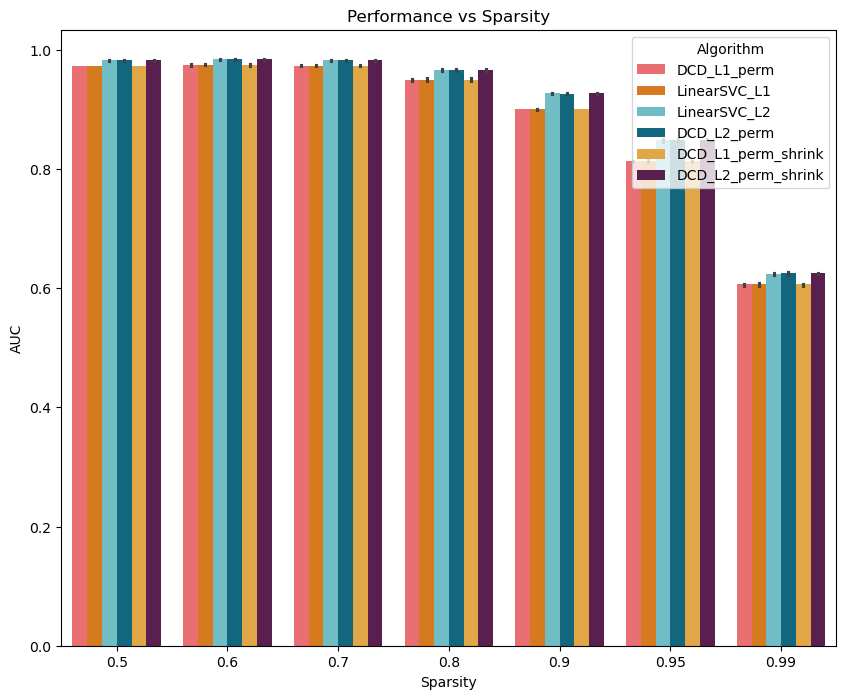

In [28]:
plt.figure(figsize=(10,8))
sns.barplot(data=phase4[phase4["method"] != "SVC_linear"], x="sparsity", y="auc", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("Sparsity")
plt.ylabel("AUC")
plt.title("Performance vs Sparsity")
plt.show()


## PHASE 5 - Convergence analysis

In [29]:
from data_loader import load_libsvm

class1_frac = {}
datasets = ["a9a", "cod_rna", "news20", "rcv1", "real-sim", "skin"]

for dataset in datasets:
    data_path = f"../data/{dataset}"
    X, y = load_libsvm(data_path)
    frac = np.sum(y == 1) / len(y)
    class1_frac[dataset] = frac

In [30]:
print(class1_frac)

{'a9a': np.float64(0.23928176569346055), 'cod_rna': np.float64(0.12075207642459461), 'news20': np.float64(0.5000500100020004), 'rcv1': np.float64(0.5182788262029444), 'real-sim': np.float64(0.30754124659447646), 'skin': np.float64(0.2075403173152259)}


In [31]:
df_frac = (
pd.DataFrame.from_dict(
        class1_frac,
        orient="index",
        columns=["frac"]
    )
    .reset_index()
    .rename(columns={"index": "dataset"})
)

phase5 = pd.merge(phase5, df_frac, how="right", on='dataset')

In [32]:
phase5["time_s"] = (
    phase5["time_s"]
    .replace(["Timeout >500s", "Skipped (prior timeout)"], 500)
    .astype(float)
)

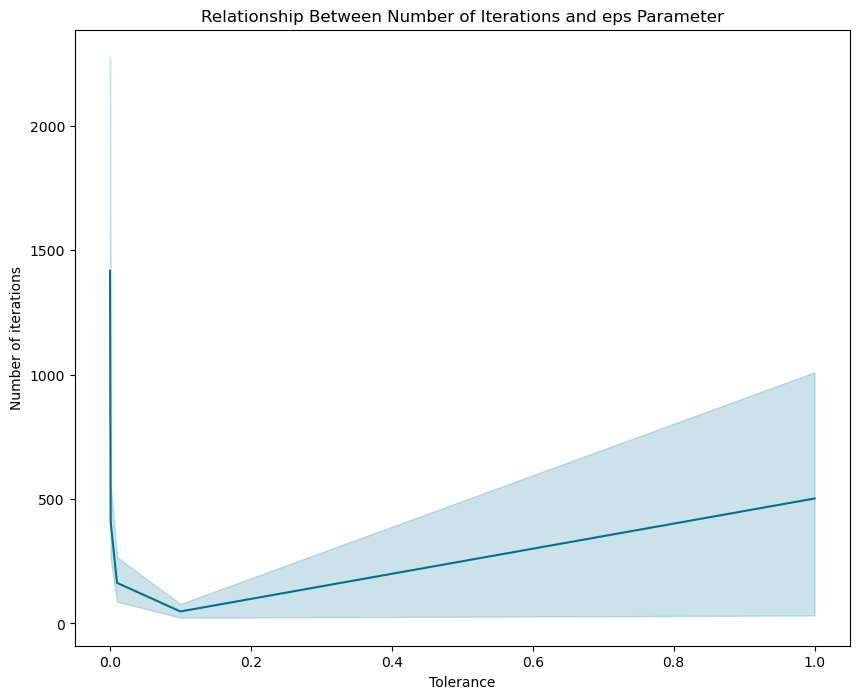

In [33]:
plt.figure(figsize=(10,8))
sns.lineplot(data=phase5, x="tol", y="n_iter")
plt.xlabel("Tolerance")
plt.ylabel("Number of iterations")
plt.title("Relationship Between Number of Iterations and eps Parameter")
plt.show()

## Additional Visualizations

In [8]:
METHOD_COLORS_EXT = {
    "DCD_L1":             "#ffb0b3",  
    "DCD_L1_shrink":      "#ff8a8e",
    "DCD_L1_perm":        "#ff5a5e", 
    "DCD_L1_perm_shrink": "#d4444a", 
    "DCD_L2":             "#9dd5de", 
    "DCD_L2_shrink":      "#62c8d3",
    "DCD_L2_perm":        "#007191",  
    "DCD_L2_perm_shrink": "#005670", 
    "LinearSVC_L1":       "#f47a00",
    "LinearSVC_L2":       "#fbac2b",
    "SVC_linear":         "#c31e23",
}

MARKERS = {
    "DCD_L1": "^", "DCD_L1_shrink": "p", "DCD_L1_perm": "o", "DCD_L1_perm_shrink": "s",
    "DCD_L2": "<", "DCD_L2_shrink": "h", "DCD_L2_perm": "D", "DCD_L2_perm_shrink": "v",
    "LinearSVC_L1": "P", "LinearSVC_L2": "X", "SVC_linear": "*",
}


### Accuracy vs training time

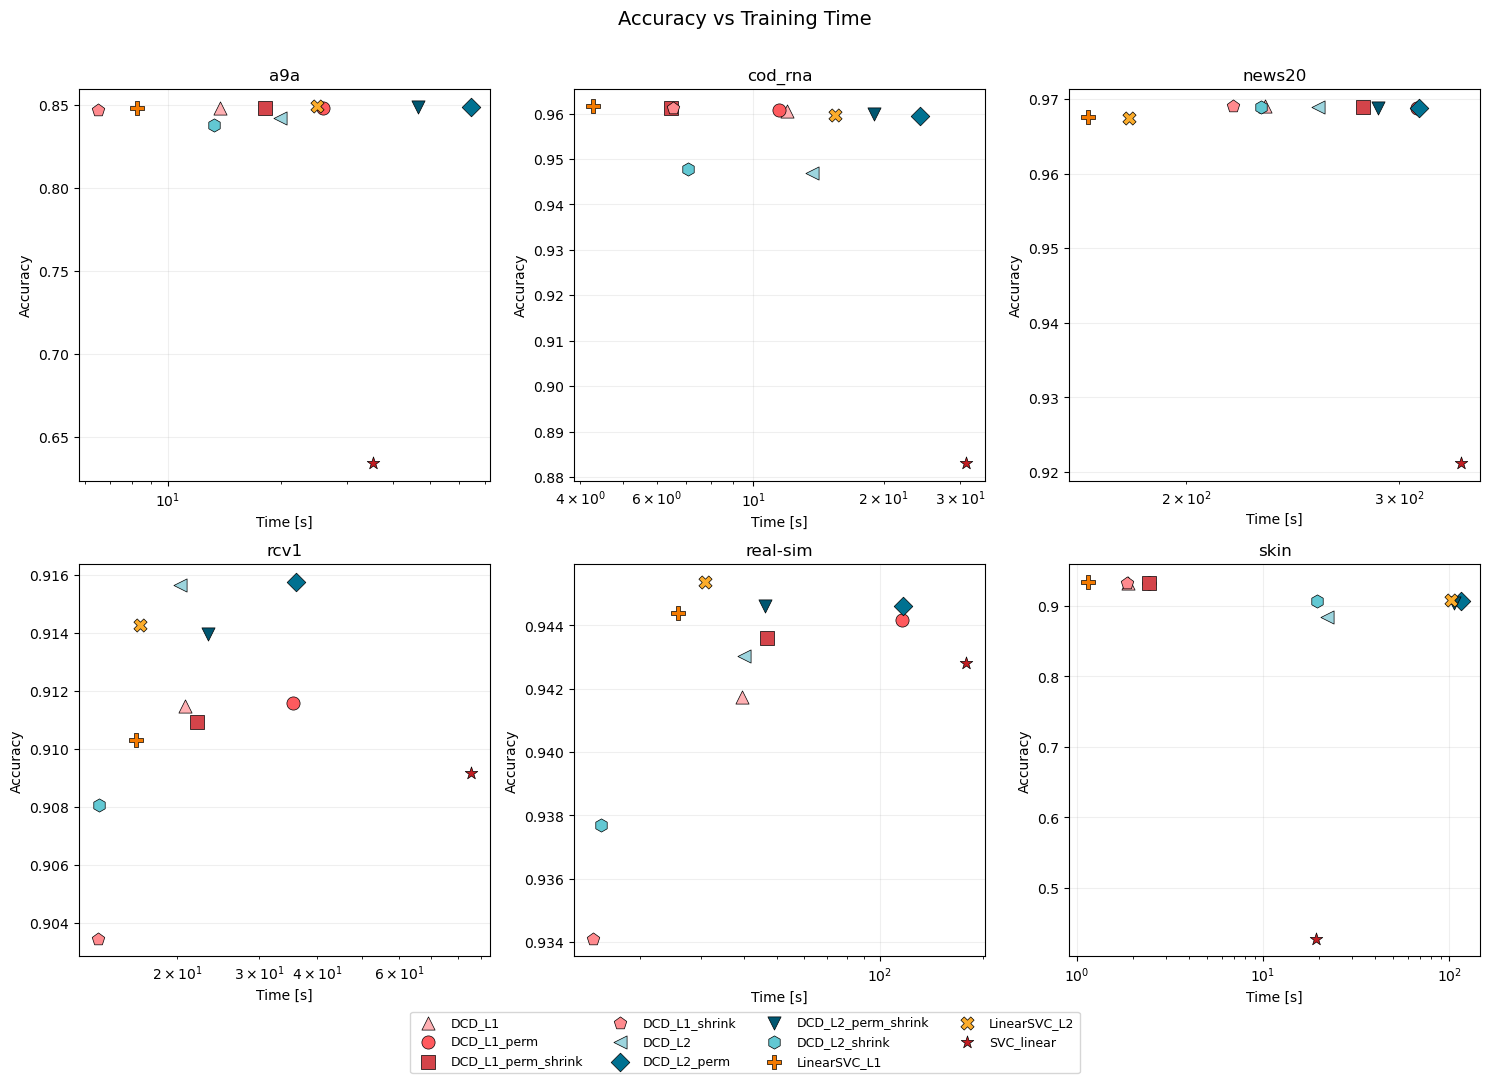

In [35]:
p1_pareto = phase1[~phase1['method'].str.contains('online')].copy()
datasets = sorted(p1_pareto['dataset'].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, ds in enumerate(datasets):
    ax = axes[idx]
    sub = p1_pareto[p1_pareto['dataset'] == ds]
    agg = sub.groupby('method')[['accuracy', 'time_s']].mean()

    for method, row in agg.iterrows():
        color = METHOD_COLORS_EXT.get(method, 'gray')
        marker = MARKERS.get(method, 'o')
        ax.scatter(row['time_s'], row['accuracy'],
                   c=color, marker=marker, s=90, zorder=3,
                   label=method, edgecolors='black', linewidths=0.5)

    ax.set_title(ds, fontsize=12)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Accuracy')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.2)

for j in range(len(datasets), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), frameon=True, fontsize=9)
fig.suptitle('Accuracy vs Training Time', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()


### Shrinking Speedup Heatmap

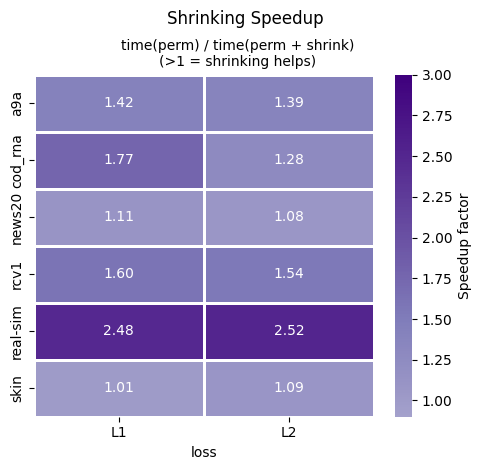

In [ ]:
rows = []

for loss in ['L1', 'L2']:
    perm = phase1[phase1['method'] == f'DCD_{loss}_perm'].groupby('dataset')['time_s'].mean()
    shrk = phase1[phase1['method'] == f'DCD_{loss}_perm_shrink'].groupby('dataset')['time_s'].mean()
    for ds in perm.index:
        rows.append({'dataset': ds, 'loss': loss, 'speedup': perm[ds] / shrk[ds]})

pivot = pd.DataFrame(rows).pivot(index='dataset', columns='loss', values='speedup')

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Purples', center=1.0,
            linewidths=1, ax=ax, cbar_kws={'label': 'Speedup factor'},
            vmin=0.9, vmax=3.0)
plt.suptitle('Shrinking Speedup', y=0.93)
ax.set_title('\ntime(perm) / time(perm + shrink)\n(>1 = shrinking helps)', x=0.6, fontsize=10)
ax.set_ylabel('')
fig.tight_layout()
plt.show()


### Permutation Effect Heatmap

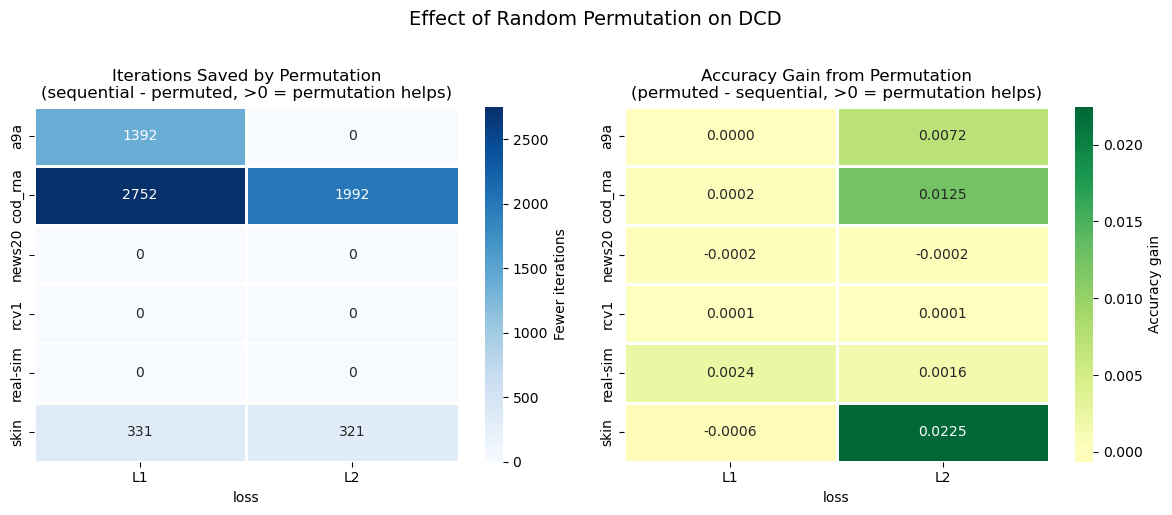

In [37]:
rows = []
for loss in ['L1', 'L2']:
    base = phase1[phase1['method'] == f'DCD_{loss}'].groupby('dataset')[['n_iter', 'accuracy']].mean()
    perm = phase1[phase1['method'] == f'DCD_{loss}_perm'].groupby('dataset')[['n_iter', 'accuracy']].mean()
    for ds in base.index:
        rows.append({
            'dataset': ds, 'loss': loss,
            'iter_saved': base.loc[ds, 'n_iter'] - perm.loc[ds, 'n_iter'],
            'acc_gain': perm.loc[ds, 'accuracy'] - base.loc[ds, 'accuracy'],
        })

df_perm = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

piv1 = df_perm.pivot(index='dataset', columns='loss', values='iter_saved')
sns.heatmap(piv1, annot=True, fmt='.0f', cmap='Blues', linewidths=1, ax=ax1,
            cbar_kws={'label': 'Fewer iterations'})
ax1.set_title('Iterations Saved by Permutation\n(sequential - permuted, >0 = permutation helps)')
ax1.set_ylabel('')

piv2 = df_perm.pivot(index='dataset', columns='loss', values='acc_gain')
sns.heatmap(piv2, annot=True, fmt='.4f', cmap='RdYlGn', center=0, linewidths=1, ax=ax2,
            cbar_kws={'label': 'Accuracy gain'})
ax2.set_title('Accuracy Gain from Permutation\n(permuted - sequential, >0 = permutation helps)')
ax2.set_ylabel('')

fig.suptitle('Effect of Random Permutation on DCD', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


### Time Complexity Scaling (SUSY)

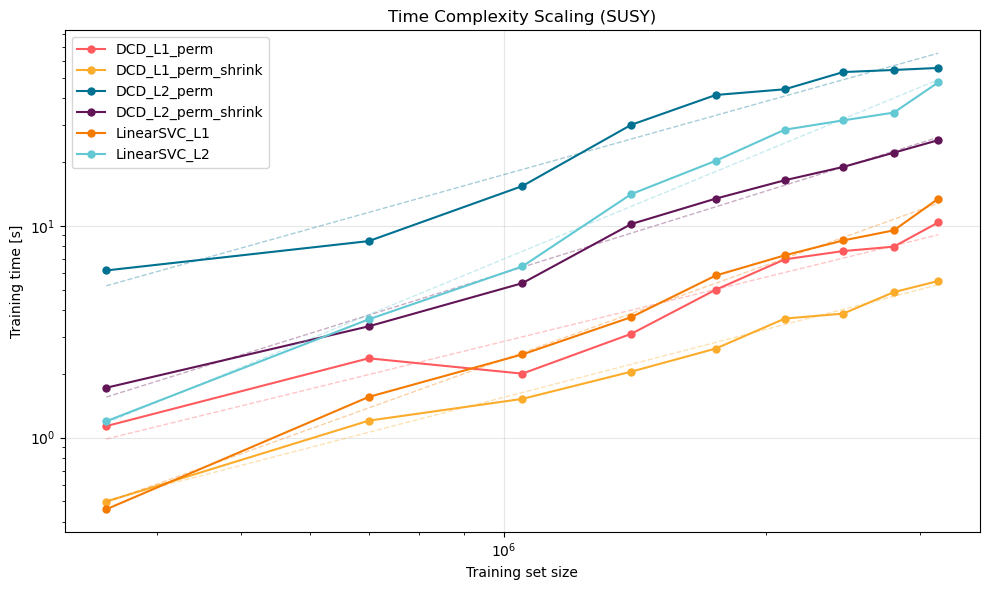

In [38]:
from scipy import stats

p3_scale = phase3.copy()
p3_scale['time_s'] = pd.to_numeric(p3_scale['time_s'], errors='coerce')
p3_scale = p3_scale[p3_scale['time_s'].notna()]
p3_scale['n_train'] = (p3_scale['fraction'] * total_rows * 0.7).astype(int)
p3_scale = p3_scale[p3_scale['method'] != 'SVC_linear']

fig, ax = plt.subplots(figsize=(10, 6))

for method in sorted(p3_scale['method'].unique()):
    sub = p3_scale[p3_scale['method'] == method]
    agg = sub.groupby('n_train')['time_s'].mean().reset_index()
    color = METHOD_COLORS.get(method, METHOD_COLORS_EXT.get(method, 'gray'))

    ax.plot(agg['n_train'], agg['time_s'], 'o-', color=color,
            label=method, markersize=5, linewidth=1.5)

    log_n = np.log10(agg['n_train'].values)
    log_t = np.log10(agg['time_s'].values)
    slope, intercept, *_ = stats.linregress(log_n, log_t)
    ax.plot(agg['n_train'], 10 ** (intercept + slope * log_n),
            '--', color=color, alpha=0.35, linewidth=1)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Training set size')
ax.set_ylabel('Training time [s]')
ax.set_title('Time Complexity Scaling (SUSY)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


In [49]:
DATA_DIR = "../results/convergence"
 
#DATASETS = ["a9a", "cod_rna", "real-sim", "rcv1", "news20", "skin"]
DATASETS = ["a9a", "real-sim", "rcv1", "skin"]
 
METHOD_COLORS = {
    "DCD_L1_perm":        "#e74c3c",
    "DCD_L1_perm_shrink": "#a93226",
    "DCD_L1":             "#f5b7b1",
    "DCD_L2_perm":        "#2980b9",
    "DCD_L2_perm_shrink": "#1a5276",
    "DCD_L2":             "#aed6f1",
}
 
METHOD_ORDER = [
    "DCD_L1_perm", "DCD_L1_perm_shrink", "DCD_L1",
    "DCD_L2_perm", "DCD_L2_perm_shrink", "DCD_L2",
]
 
SEEDS = [42, 142, 242]
SEED_ALPHA = {42: 1.0, 142: 0.55, 242: 0.55}
SEED_LW    = {42: 1.4, 142: 0.8,  242: 0.8}
 
OUT_DIR = "../results/plots"
os.makedirs(OUT_DIR, exist_ok=True)
 
 
def load_all():
    data = defaultdict(lambda: defaultdict(dict))
    patterns = [
        os.path.join(DATA_DIR, "*.json"),
    ]
    files = []
    for p in patterns:
        files.extend(glob.glob(p))
 
    for fp in sorted(files):
        fn = os.path.basename(fp)
        if "_seed" not in fn:
            continue
        parts = fn.rsplit("_seed", 1)
        if len(parts) != 2:
            continue
        prefix = parts[0]
        seed_str = parts[1].replace(".json", "")
        try:
            seed = int(seed_str)
        except ValueError:
            continue
 
        dcd_idx = prefix.find("_DCD_")
        if dcd_idx < 0:
            continue
        ds = prefix[:dcd_idx]
        method = prefix[dcd_idx + 1:]
 
        with open(fp) as f:
            hist = json.load(f)
        data[ds][method][seed] = hist
 
    return dict(data)
 

def _sorted_methods(methods_dict):
    present = set(methods_dict.keys())
    ordered = [m for m in METHOD_ORDER if m in present]
    ordered += sorted(present - set(ordered))
    return ordered
 
 
def _setup_grid(datasets, suptitle, figw_per=6.0, row_h=4.8,
                legend_space=0.06):
    n = len(datasets)
    ncols = min(n, 2)
    nrows = max(1, (n + ncols - 1) // ncols)
    figw = figw_per * ncols
    figh = row_h * nrows + 0.6          
    fig, axes = plt.subplots(nrows, ncols, figsize=(figw, figh),
                             squeeze=False)
    fig.suptitle(suptitle, fontsize=15, fontweight="bold", y=1.01)
    flat = axes.flatten()
    for i in range(n, len(flat)):
        flat[i].set_visible(False)
    return fig, flat[:n]
 
 
def _add_fig_legend(fig, methods_dict):
    handles = []
    for m in _sorted_methods(methods_dict):
        c = METHOD_COLORS.get(m, "gray")
        handles.append(Line2D([0], [0], color=c, lw=1.6, label=m))
    fig.legend(handles=handles, loc="lower center",
               ncol=min(len(handles), 6), fontsize=12,
               framealpha=0.9, edgecolor="none",
               bbox_to_anchor=(0.5, -0.02))
 
 
def _add_legend(ax, methods_dict):
    handles = []
    for m in _sorted_methods(methods_dict):
        c = METHOD_COLORS.get(m, "gray")
        handles.append(Line2D([0], [0], color=c, lw=1.6, label=m))
    ax.legend(handles=handles, fontsize=12, loc="best",
              framealpha=0.85, edgecolor="none")
    
print("Loading convergence histories ...")
conv_data = load_all()
found_ds = sorted(conv_data.keys())
print(f"  Found datasets: {found_ds}")
for ds in found_ds:
    for m, seeds in conv_data[ds].items():
        print(f"    {ds} / {m}: seeds {sorted(seeds.keys())}")

datasets = [d for d in DATASETS if d in conv_data]
if not datasets:
    print("No data found!")
    sys.exit(1)


Loading convergence histories ...
  Found datasets: ['a9a', 'cod_rna', 'news20', 'rcv1', 'real-sim', 'skin']
    a9a / DCD_L1_perm: seeds [42, 142, 242]
    a9a / DCD_L1_perm_shrink: seeds [42, 142, 242]
    a9a / DCD_L1: seeds [42, 142, 242]
    a9a / DCD_L2_perm: seeds [42, 142, 242]
    a9a / DCD_L2_perm_shrink: seeds [42, 142, 242]
    a9a / DCD_L2: seeds [42, 142, 242]
    cod_rna / DCD_L1_perm: seeds [42, 142, 242]
    cod_rna / DCD_L1_perm_shrink: seeds [42, 142, 242]
    cod_rna / DCD_L1: seeds [42, 142, 242]
    cod_rna / DCD_L2_perm: seeds [42, 142, 242]
    cod_rna / DCD_L2_perm_shrink: seeds [42, 142, 242]
    cod_rna / DCD_L2: seeds [42, 142, 242]
    news20 / DCD_L1_perm: seeds [42, 142, 242]
    news20 / DCD_L1_perm_shrink: seeds [42, 142, 242]
    news20 / DCD_L1: seeds [42, 142, 242]
    news20 / DCD_L2_perm: seeds [42, 142, 242]
    news20 / DCD_L2_perm_shrink: seeds [42, 142, 242]
    news20 / DCD_L2: seeds [42, 142, 242]
    rcv1 / DCD_L1_perm: seeds [42, 142, 242]


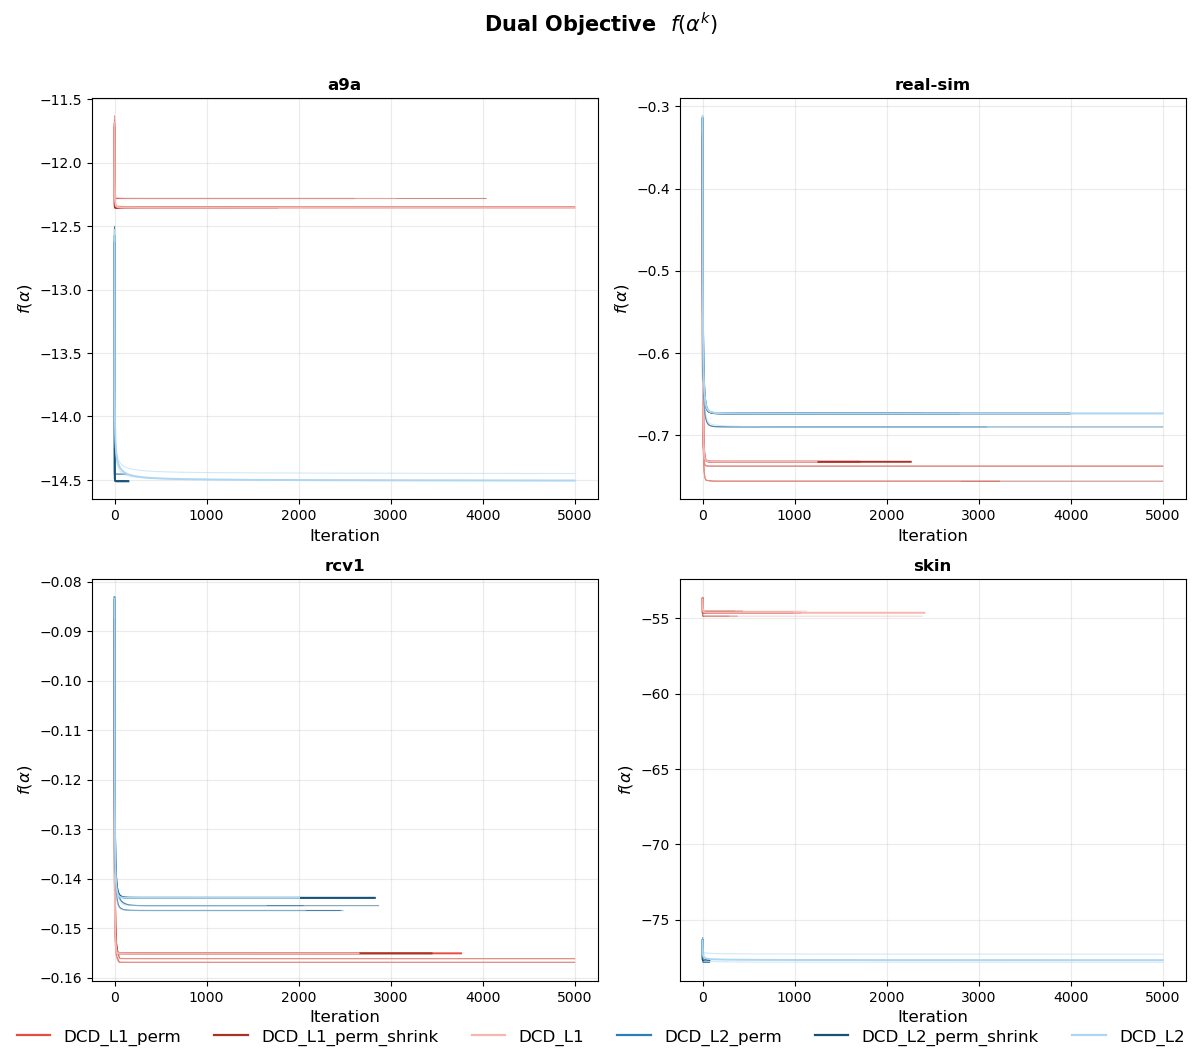

In [50]:
def plot_dual_obj(conv_data, datasets):
    fig, axes = _setup_grid(datasets,
                            "Dual Objective  $f(\\alpha^k)$")
    for ax, ds in zip(axes, datasets):
        if ds not in conv_data:
            ax.text(0.5, 0.5, f"{ds}\n(no data)", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, color="#999")
            ax.set_title(ds, fontsize=11)
            continue
        methods = conv_data[ds]
        for m in _sorted_methods(methods):
            c = METHOD_COLORS.get(m, "gray")
            for seed, hist in sorted(methods[m].items()):
                ax.plot(hist["dual_obj"], color=c,
                        alpha=SEED_ALPHA[seed], linewidth=SEED_LW[seed])
        ax.set_xlabel("Iteration", fontsize=12)
        ax.set_ylabel("$f(\\alpha)$", fontsize=12)
        ax.set_title(ds, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=10)
    _all = {}
    for ds in datasets:
        if ds in conv_data:
            _all.update(conv_data[ds])
    _add_fig_legend(fig, _all)
    fig.tight_layout()


plot_dual_obj(conv_data, datasets)

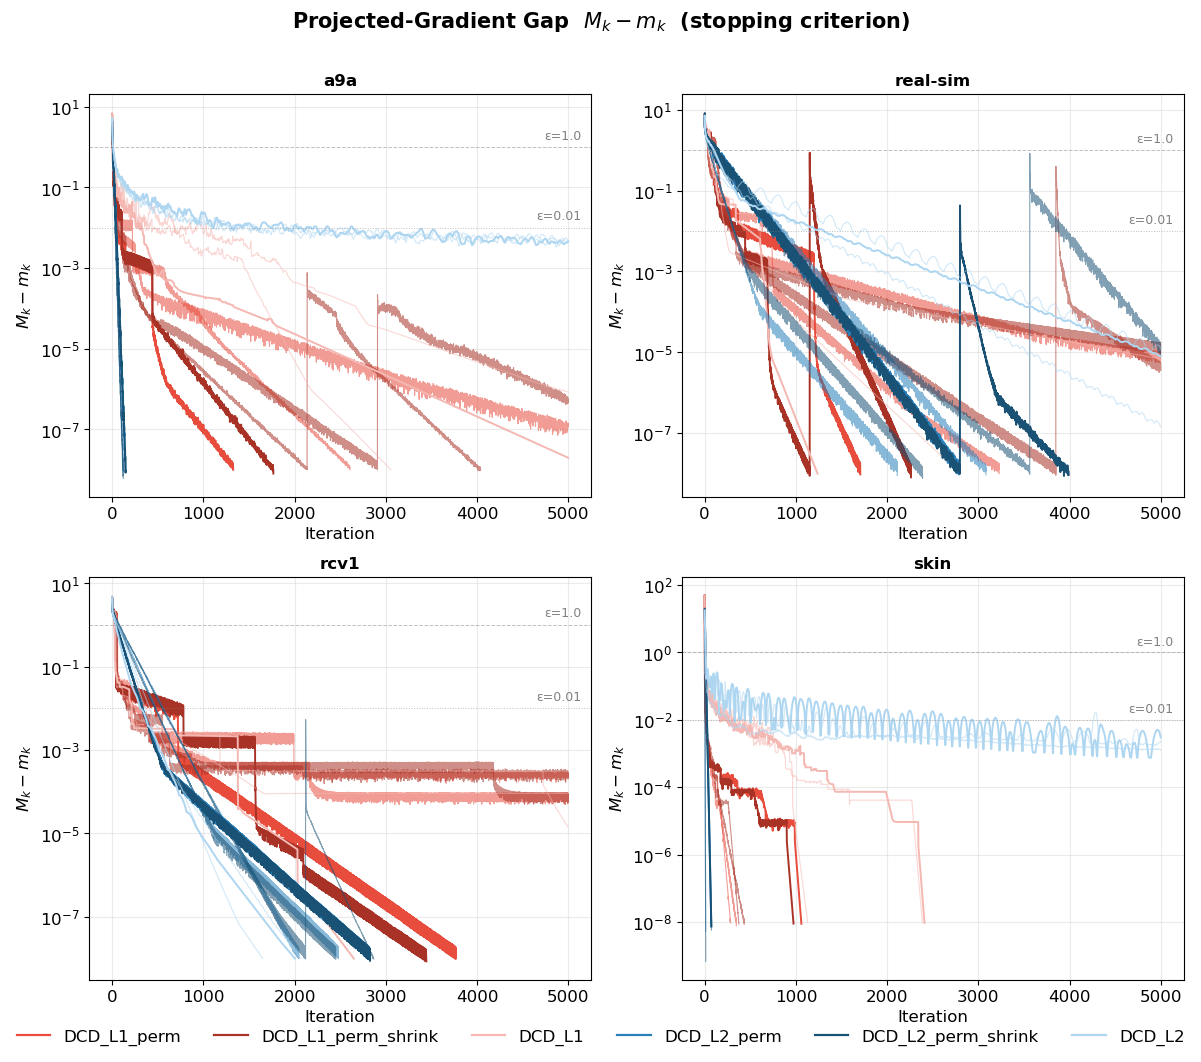

In [54]:
def plot_pg_gap(conv_data, datasets):
    fig, axes = _setup_grid(datasets,
                            "Projected-Gradient Gap  $M_k - m_k$  (stopping criterion)")
    for ax, ds in zip(axes, datasets):
        if ds not in conv_data:
            ax.text(0.5, 0.5, f"{ds}\n(no data)", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, color="#999")
            ax.set_title(ds, fontsize=11)
            continue
        methods = conv_data[ds]
        for m in _sorted_methods(methods):
            c = METHOD_COLORS.get(m, "gray")
            for seed, hist in sorted(methods[m].items()):
                gaps = [max(g, 1e-12) for g in hist["gap"]]
                ax.semilogy(gaps, color=c,
                            alpha=SEED_ALPHA[seed], linewidth=SEED_LW[seed])
        for eps, ls in [(1.0, "--"), (0.01, ":")]:
            ax.axhline(eps, color="gray", ls=ls, lw=0.7, alpha=0.5)
            ax.text(ax.get_xlim()[1] * 0.98, eps * 1.3,
                    f"ε={eps}", fontsize=9, color="gray",
                    ha="right", va="bottom")
        ax.set_xlabel("Iteration", fontsize=12)
        ax.set_ylabel("$M_k - m_k$", fontsize=12)
        ax.set_title(ds, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=12)
    _all = {}
    for ds in datasets:
        if ds in conv_data:
            _all.update(conv_data[ds])
    _add_fig_legend(fig, _all)
    fig.tight_layout()

plot_pg_gap(conv_data, datasets)

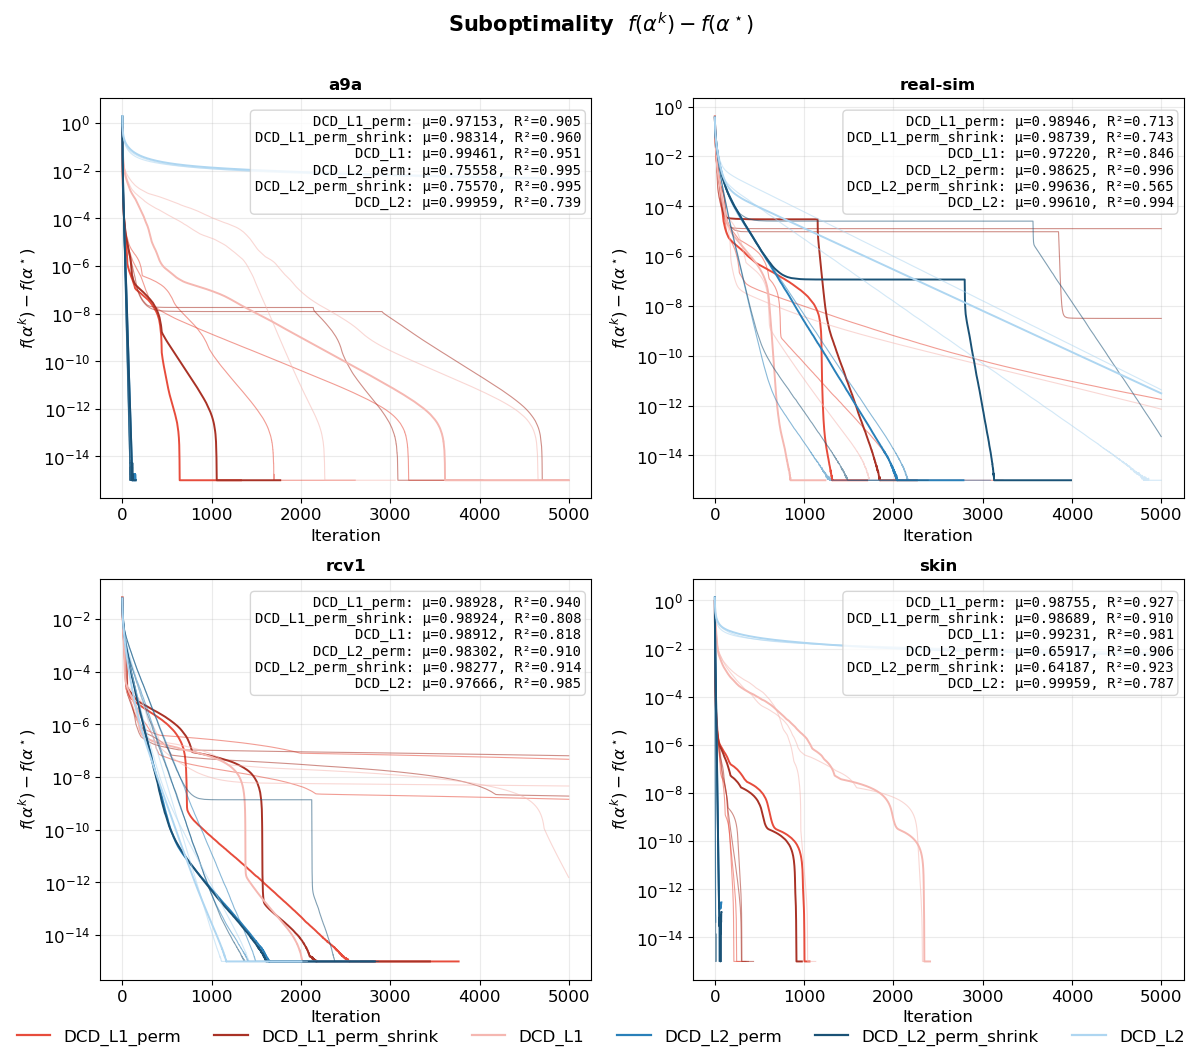

In [59]:
def plot_subopt(conv_data, datasets):
    fig, axes = _setup_grid(datasets,
                            "Suboptimality  $f(\\alpha^k) - f(\\alpha^\\star)$")
    for ax, ds in zip(axes, datasets):
        if ds not in conv_data:
            ax.text(0.5, 0.5, f"{ds}\n(no data)", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, color="#999")
            ax.set_title(ds, fontsize=11)
            continue
        methods = conv_data[ds]
        rate_labels = []
        for m in _sorted_methods(methods):
            c = METHOD_COLORS.get(m, "gray")
            all_log_sub = []
            for seed, hist in sorted(methods[m].items()):
                if "subopt" not in hist:
                    continue
                sub = [max(s, 1e-15) for s in hist["subopt"]]
                ax.semilogy(sub, color=c,
                            alpha=SEED_ALPHA[seed], linewidth=SEED_LW[seed])
                if seed == min(methods[m].keys()):
                    all_log_sub = np.log10(np.array(sub))
            if len(all_log_sub) > 50:
                valid = np.isfinite(all_log_sub) & (all_log_sub > -14)
                if valid.sum() > 50:
                    iters = np.arange(len(all_log_sub))
                    slope, intercept, r, _, _ = linregress(
                        iters[valid], all_log_sub[valid])
                    mu = 10 ** slope 
                    rate_labels.append(f"{m}: μ={mu:.5f}, R²={r**2:.3f}")
        ax.set_xlabel("Iteration", fontsize=12)
        ax.set_ylabel("$f(\\alpha^k) - f(\\alpha^\\star)$", fontsize=12)
        ax.set_title(ds, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=12)
        if rate_labels:
            txt = "\n".join(rate_labels)
            ax.text(0.98, 0.72, txt, transform=ax.transAxes,
                    fontsize=10, fontfamily="monospace",
                    ha="right", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.3",
                              facecolor="white", alpha=0.8, edgecolor="#ccc"))
    _all = {}
    for ds in datasets:
        if ds in conv_data:
            _all.update(conv_data[ds])
    _add_fig_legend(fig, _all)
    fig.tight_layout()



plot_subopt(conv_data, datasets)


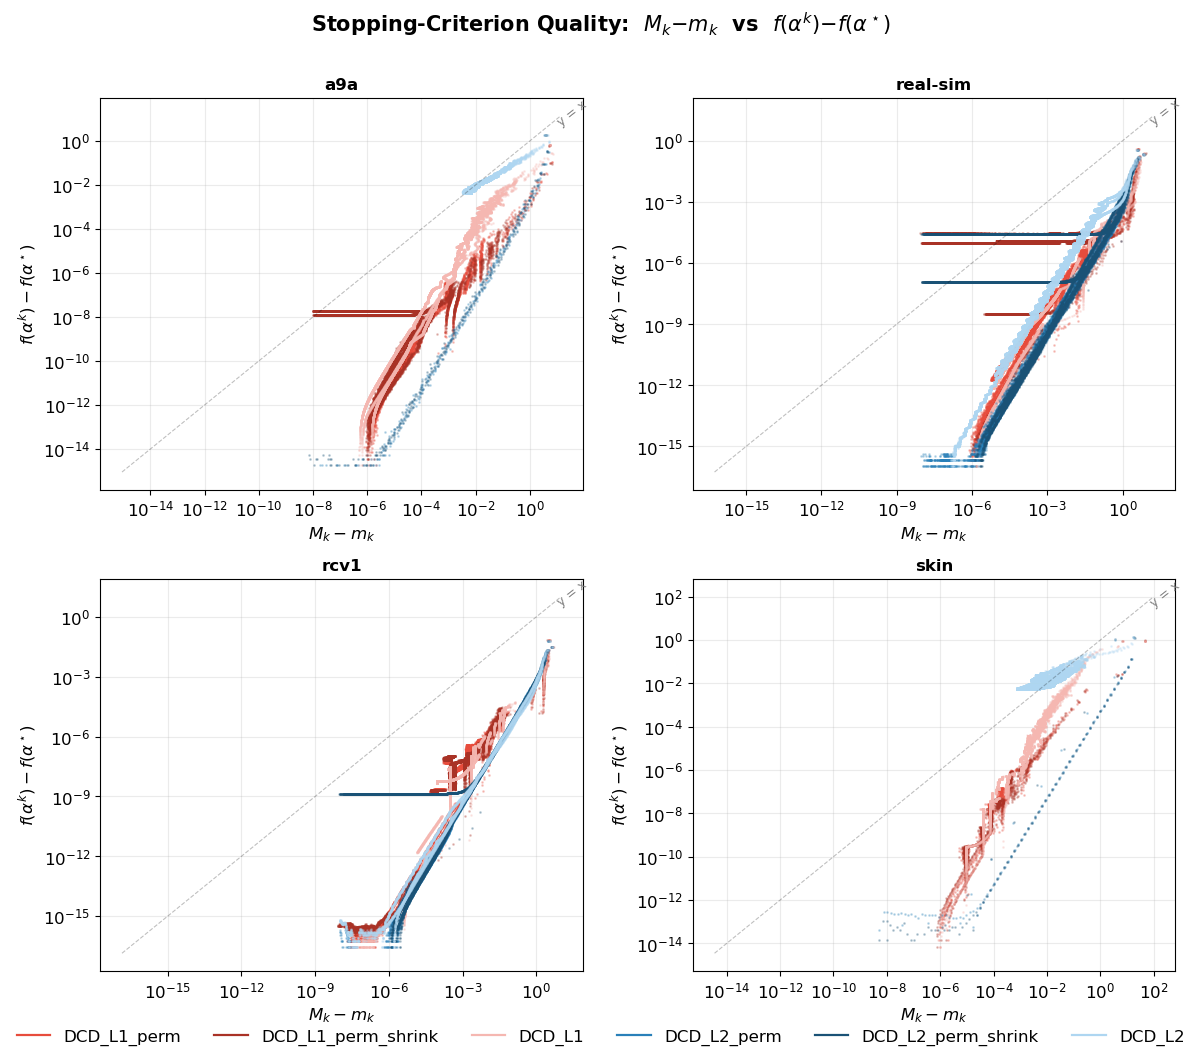

In [60]:
def plot_gap_vs_subopt(conv_data, datasets):
    fig, axes = _setup_grid(datasets,
                            "Stopping-Criterion Quality:  $M_k{-}m_k$  vs  $f(\\alpha^k){-}f(\\alpha^\\star)$")
    for ax, ds in zip(axes, datasets):
        if ds not in conv_data:
            ax.text(0.5, 0.5, f"{ds}\n(no data)", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, color="#999")
            ax.set_title(ds, fontsize=11)
            continue
        methods = conv_data[ds]
        all_gaps, all_subs = [], []
        for m in _sorted_methods(methods):
            c = METHOD_COLORS.get(m, "gray")
            for seed, hist in sorted(methods[m].items()):
                if "subopt" not in hist or "gap" not in hist:
                    continue
                g = np.array(hist["gap"])
                s = np.array(hist["subopt"])
                mask = (g > 0) & (s > 0)
                if mask.sum() < 2:
                    continue
                ax.loglog(g[mask], s[mask], ".", color=c,
                          alpha=0.25, markersize=2)
                all_gaps.extend(g[mask].tolist())
                all_subs.extend(s[mask].tolist())
        if all_gaps:
            lo = min(min(all_gaps), min(all_subs)) * 0.5
            hi = max(max(all_gaps), max(all_subs)) * 2
            ax.plot([lo, hi], [lo, hi], "k--", alpha=0.25, lw=0.8)
            ax.text(hi * 0.6, hi * 0.35, "y = x", fontsize=9,
                    color="gray", rotation=38)
        ax.set_xlabel("$M_k - m_k$", fontsize=12)
        ax.set_ylabel("$f(\\alpha^k) - f(\\alpha^\\star)$", fontsize=12)
        ax.set_title(ds, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=12)
    _all = {}
    for ds in datasets:
        if ds in conv_data:
            _all.update(conv_data[ds])
    _add_fig_legend(fig, _all)
    fig.tight_layout()




plot_gap_vs_subopt(conv_data, datasets)

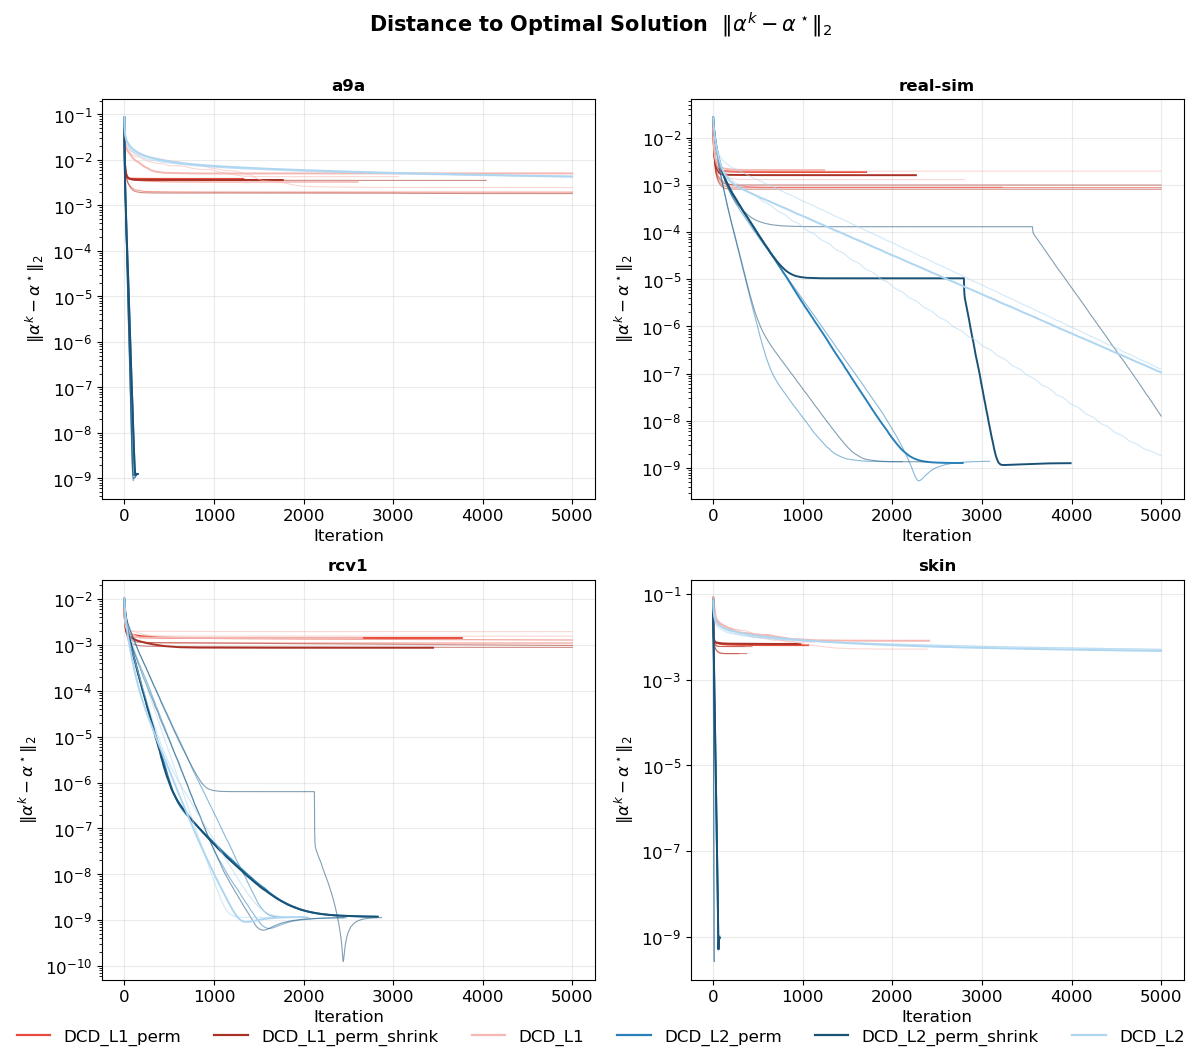

In [64]:
def plot_alpha_dist(conv_data, datasets):
    fig, axes = _setup_grid(datasets,
                            "Distance to Optimal Solution  $\\|\\alpha^k - \\alpha^\\star\\|_2$")
    for ax, ds in zip(axes, datasets):
        if ds not in conv_data:
            ax.text(0.5, 0.5, f"{ds}\n(no data)", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, color="#999")
            ax.set_title(ds, fontsize=11)
            continue
        methods = conv_data[ds]
        for m in _sorted_methods(methods):
            c = METHOD_COLORS.get(m, "gray")
            for seed, hist in sorted(methods[m].items()):
                if "alpha_dist" not in hist:
                    continue
                ad = [max(a, 1e-15) for a in hist["alpha_dist"]]
                ax.semilogy(ad, color=c,
                            alpha=SEED_ALPHA[seed], linewidth=SEED_LW[seed])
        ax.set_xlabel("Iteration", fontsize=12)
        ax.set_ylabel("$\\|\\alpha^k - \\alpha^\\star\\|_2$", fontsize=12)
        ax.set_title(ds, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=12)
    _all = {}
    for ds in datasets:
        if ds in conv_data:
            _all.update(conv_data[ds])
    _add_fig_legend(fig, _all)
    fig.tight_layout()


plot_alpha_dist(conv_data, datasets)

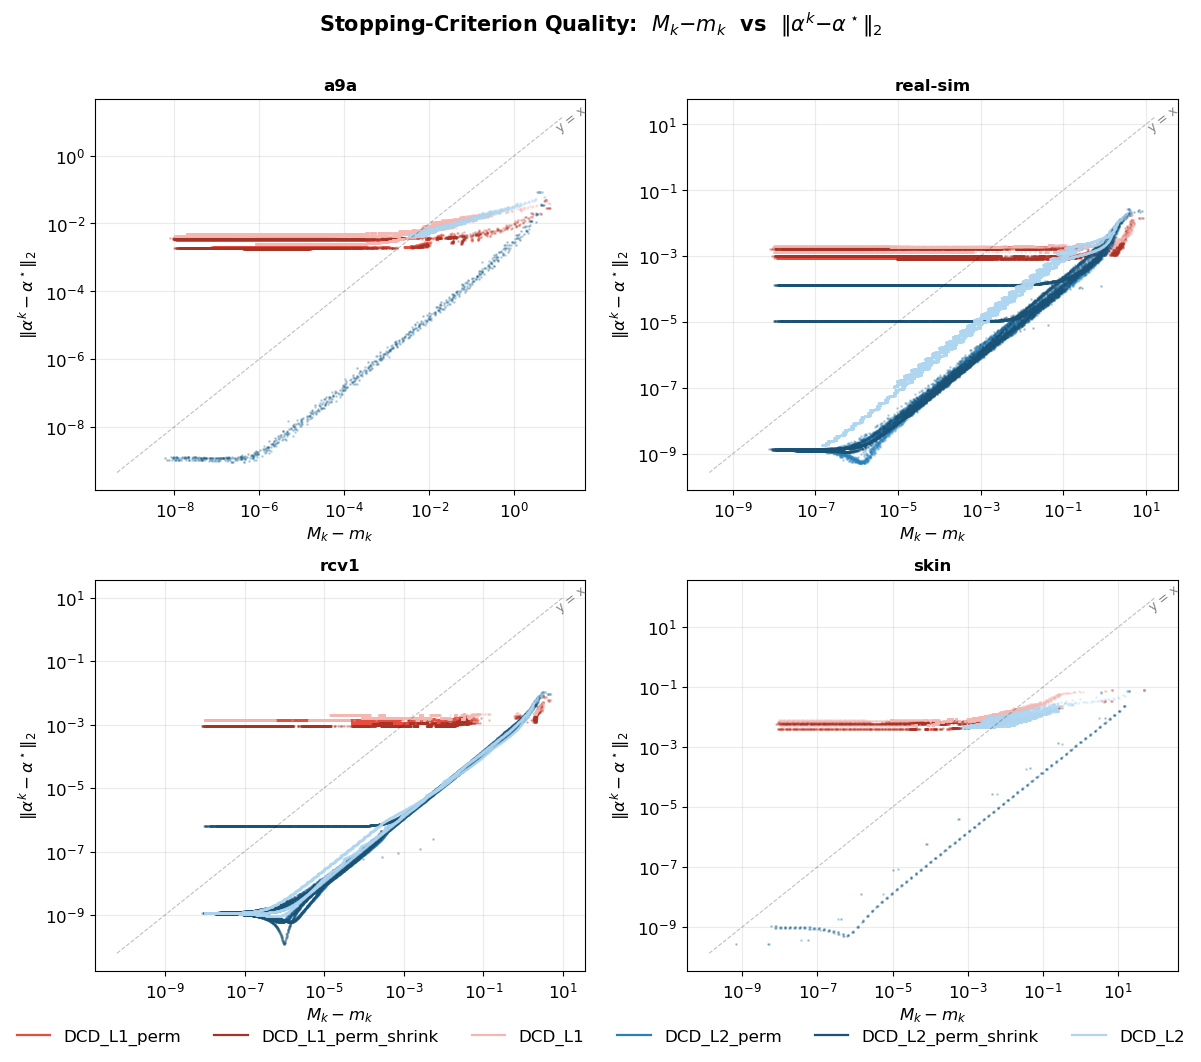

In [62]:
def plot_gap_vs_alpha_dist(conv_data, datasets):
    fig, axes = _setup_grid(datasets,
                            "Stopping-Criterion Quality:  $M_k{-}m_k$  vs  $\\|\\alpha^k{-}\\alpha^\\star\\|_2$")
    for ax, ds in zip(axes, datasets):
        if ds not in conv_data:
            ax.text(0.5, 0.5, f"{ds}\n(no data)", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, color="#999")
            ax.set_title(ds, fontsize=11)
            continue
        methods = conv_data[ds]
        all_gaps, all_dists = [], []
        for m in _sorted_methods(methods):
            c = METHOD_COLORS.get(m, "gray")
            for seed, hist in sorted(methods[m].items()):
                if "alpha_dist" not in hist or "gap" not in hist:
                    continue
                g = np.array(hist["gap"])
                d = np.array(hist["alpha_dist"])
                mask = (g > 0) & (d > 0)
                if mask.sum() < 2:
                    continue
                ax.loglog(g[mask], d[mask], ".", color=c,
                          alpha=0.25, markersize=2)
                all_gaps.extend(g[mask].tolist())
                all_dists.extend(d[mask].tolist())
        if all_gaps:
            lo = min(min(all_gaps), min(all_dists)) * 0.5
            hi = max(max(all_gaps), max(all_dists)) * 2
            ax.plot([lo, hi], [lo, hi], "k--", alpha=0.25, lw=0.8)
            ax.text(hi * 0.6, hi * 0.35, "y = x", fontsize=9,
                    color="gray", rotation=38)
        ax.set_xlabel("$M_k - m_k$", fontsize=12)
        ax.set_ylabel("$\\|\\alpha^k - \\alpha^\\star\\|_2$", fontsize=12)
        ax.set_title(ds, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=12)
    _all = {}
    for ds in datasets:
        if ds in conv_data:
            _all.update(conv_data[ds])
    _add_fig_legend(fig, _all)
    fig.tight_layout()


plot_gap_vs_alpha_dist(conv_data, datasets)


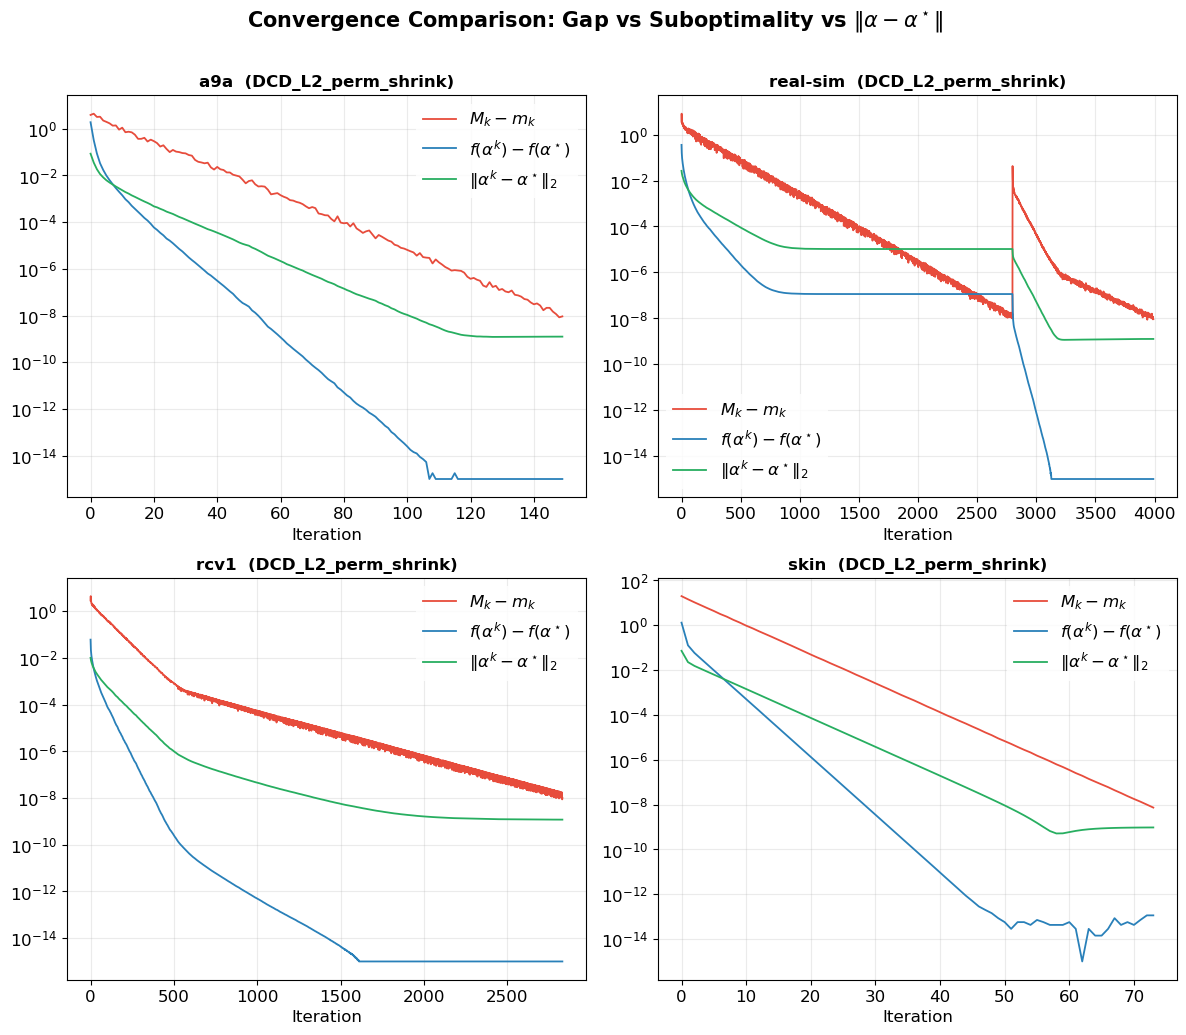

In [ ]:
def plot_convergence_comparison(conv_data, datasets):
    fig, axes = _setup_grid(datasets,
                            "Convergence Comparison: Gap vs Suboptimality vs $\\|\\alpha - \\alpha^\\star\\|$")
    for ax, ds in zip(axes, datasets):
        if ds not in conv_data:
            ax.set_title(ds, fontsize=11)
            continue
        methods = conv_data[ds]
        rep_method = None
        for pref in ["DCD_L2_perm_shrink", "DCD_L2_perm", "DCD_L1_perm_shrink", "DCD_L1_perm"]:
            if pref in methods:
                rep_method = pref
                break
        if rep_method is None:
            rep_method = list(methods.keys())[0]
        rep_seed = min(methods[rep_method].keys())
        hist = methods[rep_method][rep_seed]
 
        iters = np.arange(len(hist["gap"]))
        gap = np.array([max(g, 1e-15) for g in hist["gap"]])
        sub = np.array([max(s, 1e-15) for s in hist["subopt"]])
        ad  = np.array([max(a, 1e-15) for a in hist["alpha_dist"]])
 
        ax.semilogy(iters, gap, color="#e74c3c", lw=1.3, label="$M_k - m_k$")
        ax.semilogy(iters, sub, color="#2980b9", lw=1.3, label="$f(\\alpha^k) - f(\\alpha^\\star)$")
        ax.semilogy(iters, ad,  color="#27ae60", lw=1.3, label="$\\|\\alpha^k - \\alpha^\\star\\|_2$")
 
        ax.set_xlabel("Iteration", fontsize=12)
        ax.set_title(f"{ds}  ({rep_method})", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=12)
        ax.legend(fontsize=12, loc="best", framealpha=0.85, edgecolor="none")
    fig.tight_layout()


plot_convergence_comparison(conv_data, datasets)